In [1]:
## Code for section 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for the entire notebook
sns.set_theme(style="whitegrid")

# 1. Load the dataset (assumed to be in the same directory)
try:
    anime_df = pd.read_csv('animes.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("Error: 'animes.csv' not found. Please ensure it is in the same directory.")

# 2. Verify requirements (>1000 rows, >8 features)
rows, cols = anime_df.shape
print(f"Dataset Shape: {rows} rows, {cols} features.")
if rows >= 1000 and cols >= 8:
    print("Requirement Check: PASSED (Sufficient rows and features).")

# 3. Display available numerical features for Unsupervised Learning
numerical_features = anime_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumerical Features Available ({len(numerical_features)}):")
print(numerical_features)

Dataset loaded successfully!
Dataset Shape: 29375 rows, 27 features.
Requirement Check: PASSED (Sufficient rows and features).

Numerical Features Available (13):
['id', 'mean_score', 'rank', 'popularity', 'num_episodes', 'average_episode_duration_seconds', 'num_list_users', 'num_scoring_users', 'watching', 'completed', 'on_hold', 'dropped', 'plan_to_watch']


## 1. Dataset Selection

For this unsupervised learning and anomaly detection analysis, we will utilize the **MyAnimeList (MAL) Dataset**, which contains structural and engagement metrics for thousands of anime titles. The dataset successfully meets all project prerequisites, containing over 1,000 observations and more than 8 primarily numerical features, with no pre-labeled anomaly column.

### Dataset Context and Origin
*   **Where it comes from:** The dataset is sourced from Kaggle, representing an exported snapshot of the MyAnimeList database.
*   **Who collected it:** It was scraped and aggregated by the Kaggle community using the official MyAnimeList API.
*   **Why it was collected:** The primary purpose of this data collection is to track audience engagement, quantify critical reception, and analyze structural trends in Japanese animation. It is commonly used to build recommendation engines and analyze sub-culture media consumption habits.

### Feature Representation
For the upcoming dimensionality reduction and clustering tasks, we will focus on the rich set of numerical variables available, which primarily capture audience engagement and structural metadata:
*   `mean_score`: The average user rating for the anime.
*   `num_episodes`: The total number of episodes in the series.
*   `average_episode_duration_seconds`: The length of an average episode, highlighting format differences (e.g., short web series vs. full feature films).
*   `rank` & `popularity`: Global rankings based on score and total list additions, respectively.
*   **Engagement Metrics:** `num_list_users`, `num_scoring_users`, `watching`, `completed`, `on_hold`, `dropped`, and `plan_to_watch`. These columns provide a granular, multi-dimensional view of how the audience interacts with the media (e.g., high drop rates might indicate polarizing content).

### Limitations and Biases
To properly interpret the unsupervised learning results later in this study, several critical data biases must be acknowledged:
1.  **Extreme Popularity Skew (Heavy Tails):** A small fraction of mainstream shows capture millions of members, while the vast majority of titles remain highly obscure. This massive variance can dominate distance-based clustering algorithms if not properly scaled.
2.  **Self-Selection Bias:** Niche or highly specific formats (like obscure 1-episode OVAs) are usually only watched and rated by dedicated fans of that specific sub-genre. This artificially inflates the `score` of unknown titles, disrupting the expected correlation between high engagement and high quality.
3.  **Format Confounding:** The dataset mixes entirely different media formats (Movies, TV series, Music Videos) into a single continuous numerical space. Without explicit labels guiding the model, algorithms might struggle to differentiate between a genuinely anomalous TV show and a perfectly standard Music Video.

--- Structural Analysis ---
Number of rows and columns: (29375, 27)

--- Missing Values ---
mean_score    10428
rank           7049
dtype: int64

--- Data Types ---
id                                    int64
mean_score                          float64
rank                                float64
popularity                            int64
num_episodes                          int64
average_episode_duration_seconds      int64
num_list_users                        int64
num_scoring_users                     int64
watching                              int64
completed                             int64
on_hold                               int64
dropped                               int64
plan_to_watch                         int64
dtype: object

--- Statistical Summary ---
                 id    mean_score          rank    popularity  num_episodes  \
count  29375.000000  18947.000000  22326.000000  29375.000000  29375.000000   
mean   34449.132391      6.394510  10926.848562  14454.396085 

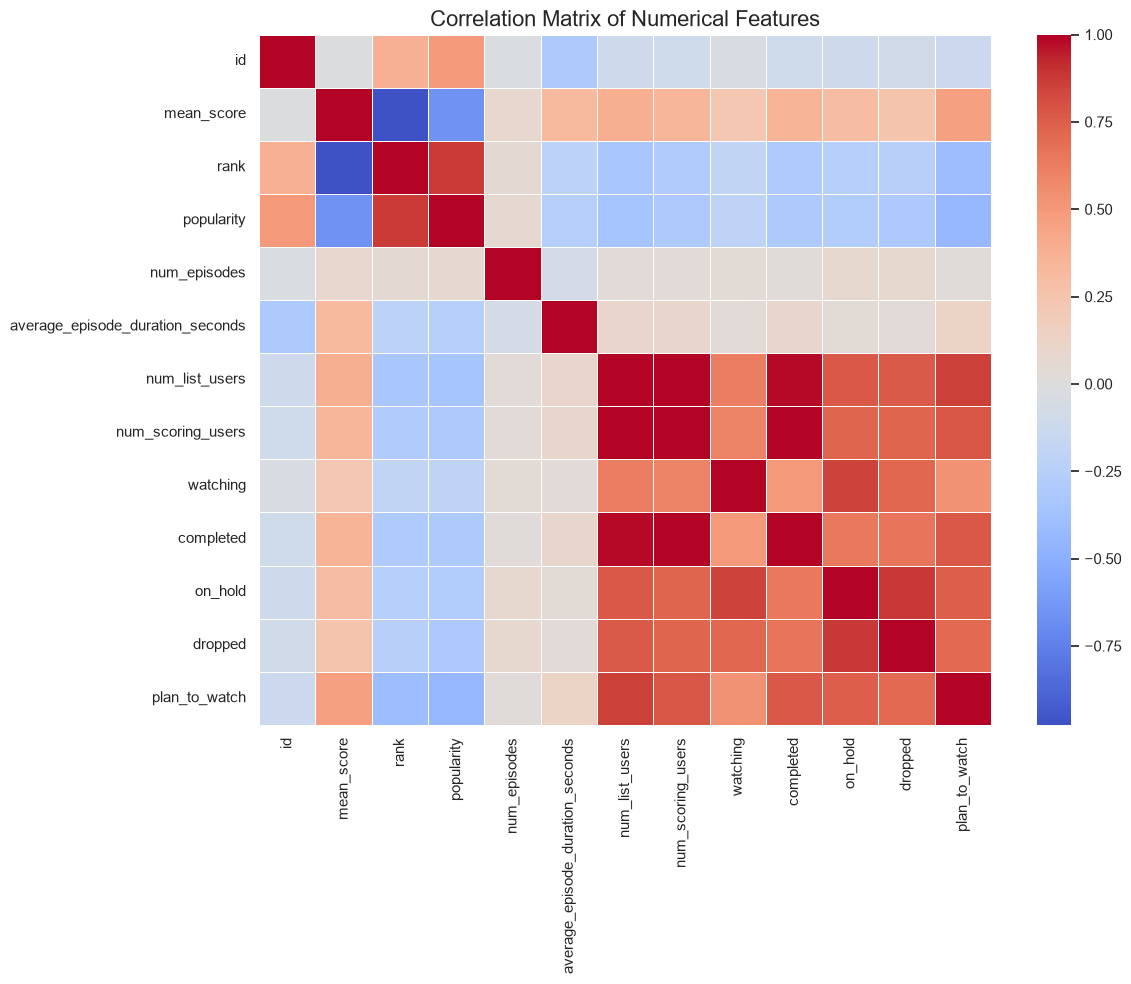


--- Distribution Analysis (Skewness & Kurtosis) ---

Feature: mean_score
Skewness: -0.0205
Kurtosis: 0.0867


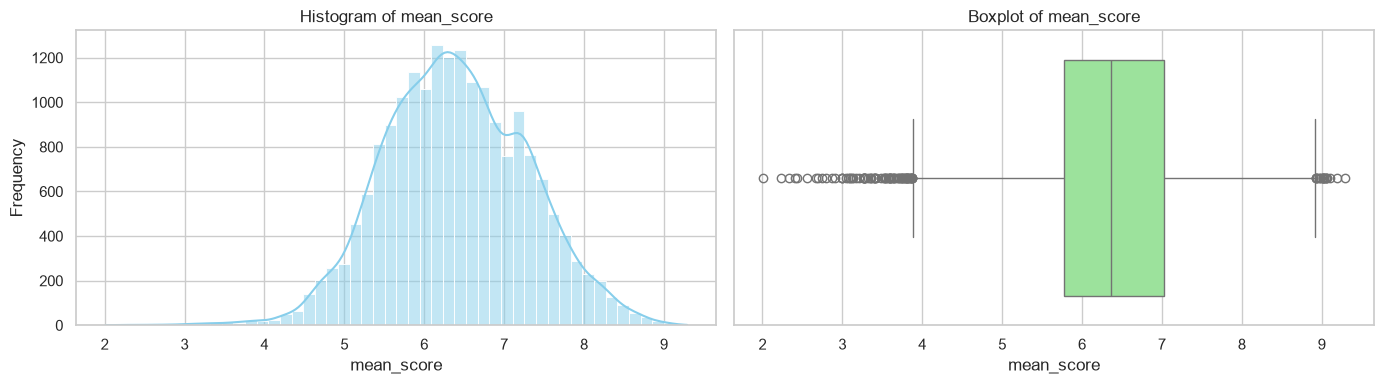


Feature: num_episodes
Skewness: 24.6260
Kurtosis: 1043.7727


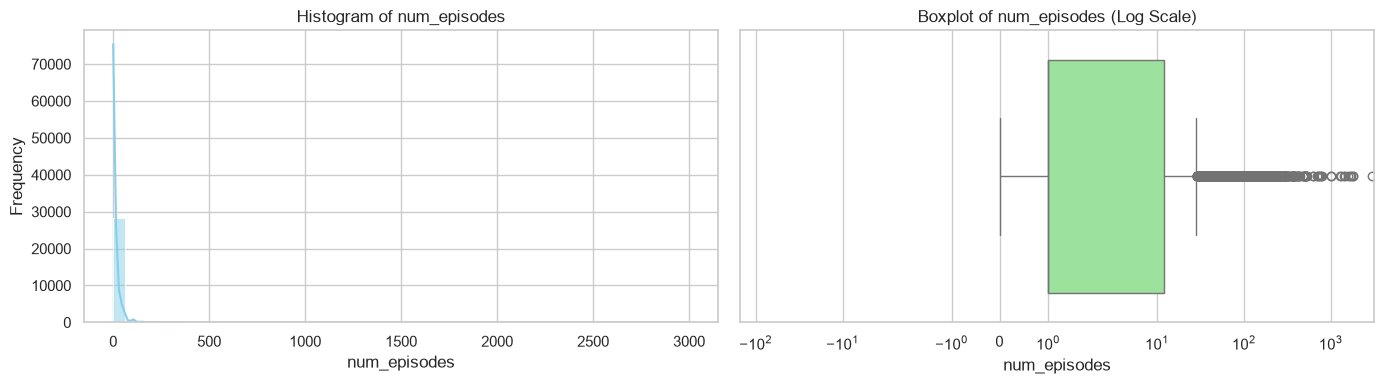


Feature: average_episode_duration_seconds
Skewness: 2.2050
Kurtosis: 5.1075


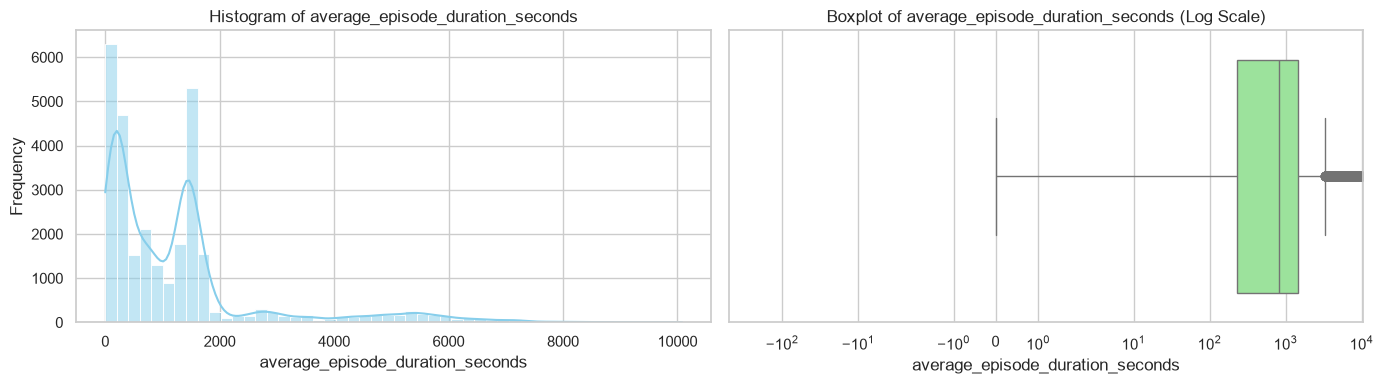


Feature: num_list_users
Skewness: 9.8750
Kurtosis: 135.0496


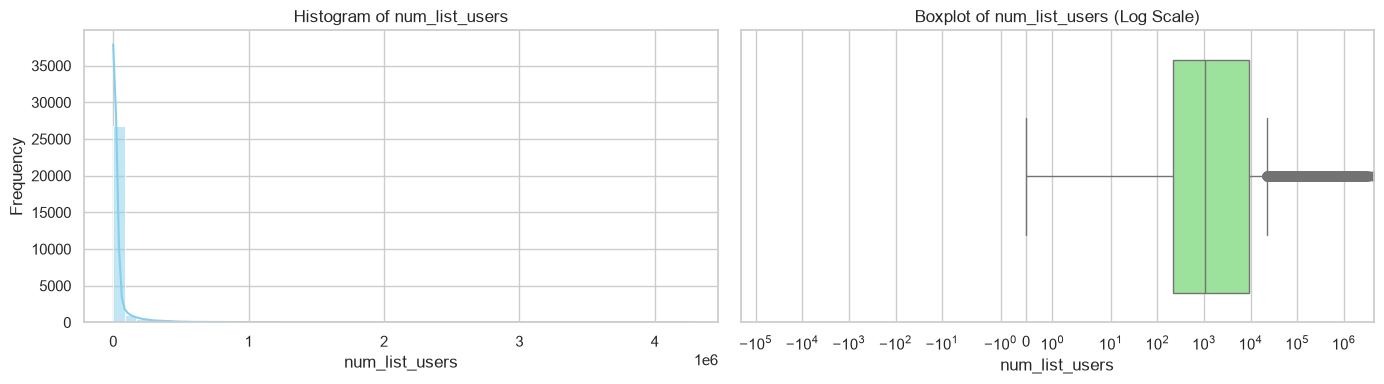


Feature: popularity
Skewness: 0.0071
Kurtosis: -1.2053


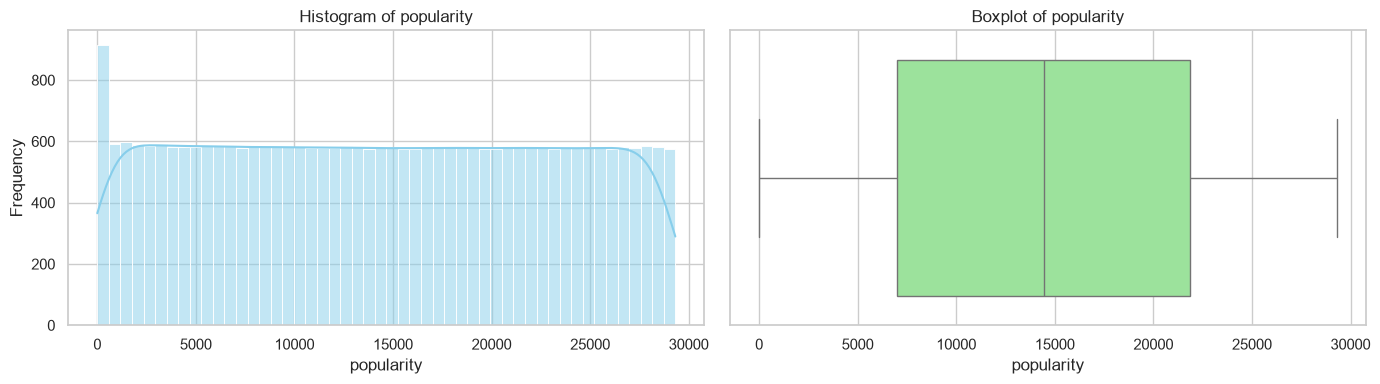

In [ ]:
## Code for section 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

print("--- Structural Analysis ---")
print(f"Number of rows and columns: {anime_df.shape}")

print("\n--- Missing Values ---")
missing_values = anime_df[numerical_features].isnull().sum()
print(missing_values[missing_values > 0]) # Print only columns with missing values

print("\n--- Data Types ---")
print(anime_df[numerical_features].dtypes)

# 1. Statistical Summary
print("\n--- Statistical Summary ---")
summary = anime_df[numerical_features].describe()
print(summary)

# 2. Correlation Matrix
plt.figure(figsize=(12, 10))
corr_matrix = anime_df[numerical_features].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5, center=0)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

# 3. Distribution Analysis & Outlier Exploration
# We focus on the most important features to provide a deep, meaningful analysis
major_features = ['mean_score', 'num_episodes', 'average_episode_duration_seconds', 'num_list_users', 'popularity']

print("\n--- Distribution Analysis (Skewness & Kurtosis) ---")
for col in major_features:
    # Drop NaNs for accurate calculation
    valid_data = anime_df[col].dropna()
    
    # Calculate Skewness and Kurtosis
    col_skew = skew(valid_data)
    col_kurt = kurtosis(valid_data)
    
    print(f"\nFeature: {col}")
    print(f"Skewness: {col_skew:.4f}")
    print(f"Kurtosis: {col_kurt:.4f}")
    
    # Plot Histogram and Boxplot side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Histogram
    sns.histplot(valid_data, bins=50, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histogram of {col}', fontsize=12)
    axes[0].set_ylabel('Frequency')
    
    # Boxplot (Using symlog scale for highly skewed variables for better visual clarity)
    sns.boxplot(x=valid_data, ax=axes[1], color='lightgreen')
    if col in ['num_episodes', 'average_episode_duration_seconds', 'num_list_users']:
        axes[1].set_xscale('symlog')
        axes[1].set_title(f'Boxplot of {col} (Log Scale)', fontsize=12)
    else:
        axes[1].set_title(f'Boxplot of {col}', fontsize=12)
        
    plt.tight_layout()
    plt.show()

## 2. Exploratory Data Analysis (EDA)

To understand the underlying geometry of the dataset prior to unsupervised modeling, we performed a comprehensive exploratory data analysis on the numerical features. Due to the high collinearity among engagement metrics, we focused our distribution analysis on five major representative features.

### Structural Analysis
*   **Dimensionality:** The dataset consists of 29,375 observations and 27 columns. 
*   **Data Types:** All selected features for this analysis are correctly parsed as continuous numerical variables (`int64` and `float64`).
*   **Missing Values:** The dataset is mostly complete, but significant missing values exist in `mean_score` (10,428 missing) and `rank` (7,049 missing). This structural missingness is not an error but a real-world artifact: highly obscure or unreleased media simply do not have enough user interactions to generate a valid score or global rank.
*   **Correlation Matrix:** The heatmap reveals a massive block of high positive correlation among all user-engagement metrics (e.g., `num_list_users`, `completed`, `watching`, `num_scoring_users`). This high collinearity suggests that dimensionality reduction techniques (like PCA) will be highly effective in condensing these variables into a single "engagement" component. Furthermore, `mean_score` is negatively correlated with `popularity` and `rank`, which is mathematically sound since lower numerical values in those columns represent a higher, better rank.

### Distribution Analysis
*   **`mean_score`:** Exhibits a near-perfect Normal Distribution. The skewness is essentially zero (-0.0205) and kurtosis is extremely low (0.0867), yielding a classic bell-shaped curve. 
*   **`popularity`:** Exhibits a Uniform Distribution (flat histogram, negative kurtosis of -1.2053). This confirms that this feature is an ordinal rank (each number from 1 to N appears roughly equally) rather than an absolute measurement.
*   **`average_episode_duration_seconds`:** Exhibits a multi-modal, right-skewed distribution. The visible spikes correspond to standard media formats: short web clips (~3-5 mins), standard TV episodes (~23 mins), and full-length movies.

### Outlier Exploration and Heavy Tails
The dataset is deeply characterized by heavy tails and extreme outliers in its absolute measurement features, specifically `num_episodes` and `num_list_users`.
*   **Heavy Tails & Skewness:** Both `num_episodes` (Skew: 24.62) and `num_list_users` (Skew: 9.87) are heavily right-skewed. The boxplots, even on a logarithmic scale, show a massive concentration of data at the lower bounds, stretching out towards extreme maximums.
*   **Extreme Values vs. Noise:** 
    *   The maximum value for `num_list_users` exceeds 4.2 million (mega-hits like *Attack on Titan*), dwarfing the median of 1,032. 
    *   The maximum value for `num_episodes` is 3,000. 
*   **Interpretation:** In many datasets, a value 100 standard deviations above the mean (like 3,000 episodes) would be considered a data-entry error or measurement artifact. However, in this cultural dataset, these are *valid anomalies*. Series like *Sazae-san* genuinely have thousands of episodes. 
*   **Implications for Unsupervised Learning:** Because these extreme values are valid data points and not noise, standard distance-based clustering algorithms (like K-Means) will be severely distorted if we do not apply robust scaling or logarithmic transformations in the preprocessing phase.

--- PCA: Explained Variance ---
PC1: 50.83% variance (Cumulative: 50.83%)
PC2: 15.24% variance (Cumulative: 66.07%)
PC3: 8.44% variance (Cumulative: 74.52%)
PC4: 7.38% variance (Cumulative: 81.90%)
PC5: 6.77% variance (Cumulative: 88.67%)
PC6: 5.03% variance (Cumulative: 93.70%)
PC7: 2.57% variance (Cumulative: 96.27%)
PC8: 1.65% variance (Cumulative: 97.92%)
PC9: 1.55% variance (Cumulative: 99.47%)
PC10: 0.52% variance (Cumulative: 99.99%)
PC11: 0.01% variance (Cumulative: 100.00%)
PC12: 0.00% variance (Cumulative: 100.00%)


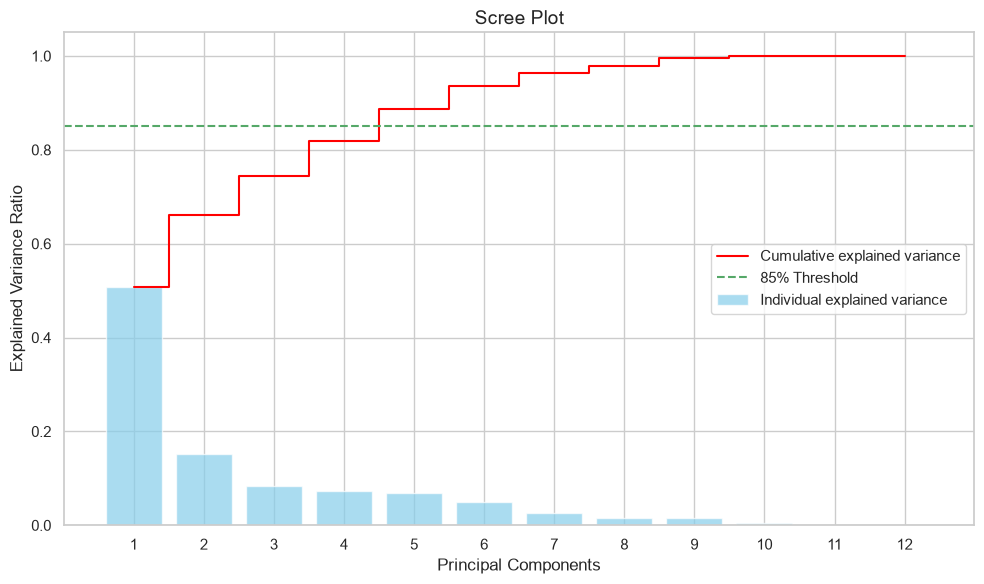


--- Feature Loadings for PC1 and PC2 ---
                                       PC1       PC2
num_list_users                    0.386491  0.104025
num_scoring_users                 0.371935  0.127614
plan_to_watch                     0.359245 -0.013677
completed                         0.357692  0.094835
on_hold                           0.352632  0.193630
dropped                           0.343813  0.178099
watching                          0.296685  0.205619
mean_score                        0.201641 -0.371423
average_episode_duration_seconds  0.065143 -0.371412
num_episodes                      0.017910  0.133412
rank                             -0.196315  0.543588
popularity                       -0.202352  0.512868


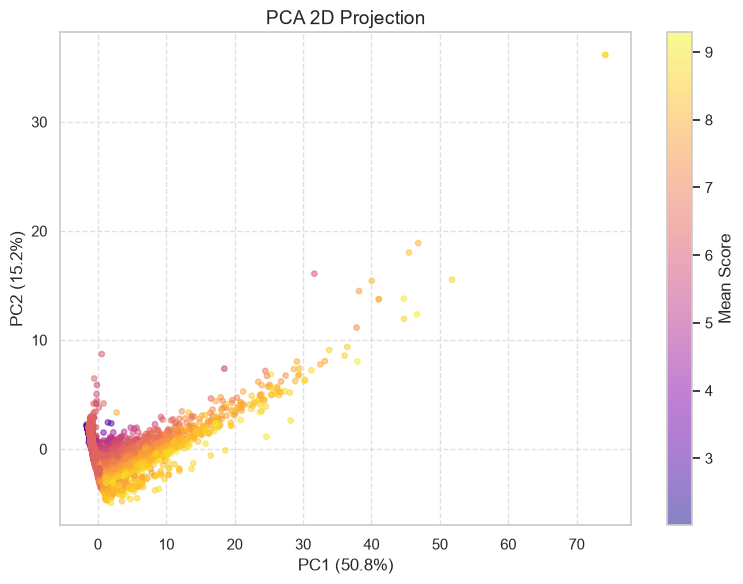

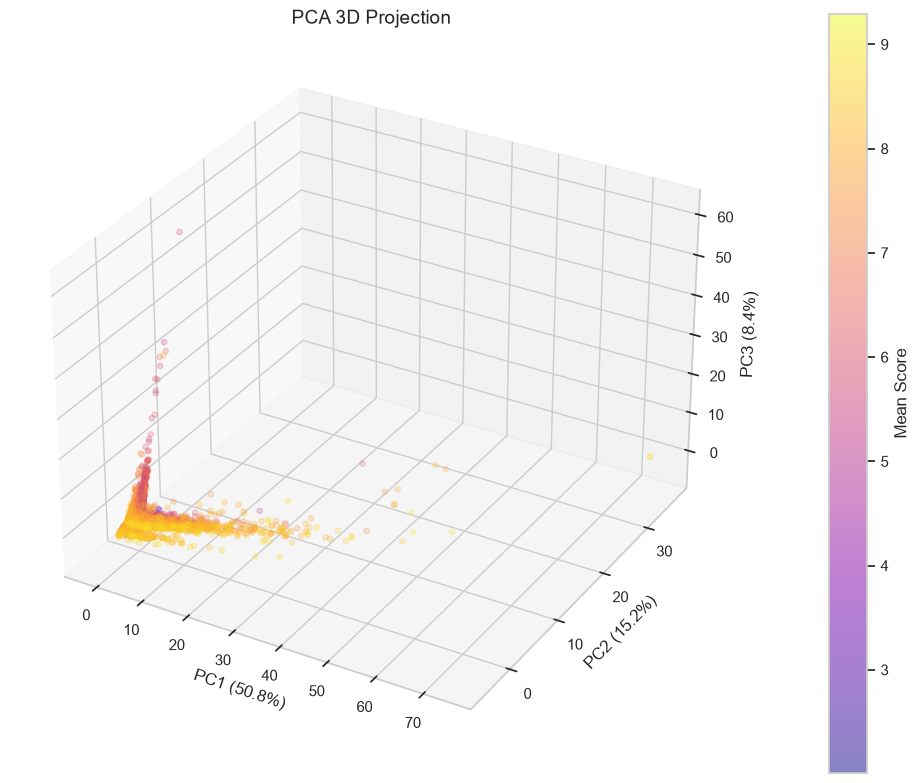

In [3]:
## Code for section 3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 1. Prepare Data for PCA
# Exclude 'id' as it is purely an identifier
pca_features = [col for col in numerical_features if col != 'id']
X_pca_raw = anime_df[pca_features].copy()

# 2. Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_pca_raw)

# 3. Standardize the data (Crucial for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 4. Apply PCA
pca = PCA()
pca.fit(X_scaled)

# 5. Extract Explained Variance
explained_var = pca.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

print("--- PCA: Explained Variance ---")
for i, (var, cum_var) in enumerate(zip(explained_var, cum_explained_var)):
    print(f"PC{i+1}: {var*100:.2f}% variance (Cumulative: {cum_var*100:.2f}%)")

# 6. Scree Plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_var) + 1), explained_var, alpha=0.7, align='center', label='Individual explained variance', color='skyblue')
plt.step(range(1, len(cum_explained_var) + 1), cum_explained_var, where='mid', color='red', label='Cumulative explained variance')
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.xlabel('Principal Components', fontsize=12)
plt.title('Scree Plot', fontsize=14)
plt.axhline(y=0.85, color='g', linestyle='--', label='85% Threshold')
plt.legend(loc='center right')
plt.xticks(range(1, len(explained_var) + 1))
plt.tight_layout()
plt.show()

# 7. Extract Feature Loadings for PC1 and PC2
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(pca_features))], index=pca_features)
print("\n--- Feature Loadings for PC1 and PC2 ---")
print(loadings[['PC1', 'PC2']].sort_values(by='PC1', ascending=False))

# 8. Dimensionality Projections (2D and 3D)
X_pca_transformed = pca.transform(X_scaled)

# 2D Projection Plot
plt.figure(figsize=(8, 6))
# Color by 'mean_score' to see if high/low ratings separate in the PCA space
scatter_2d = plt.scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], 
                         c=X_imputed[:, pca_features.index('mean_score')], 
                         cmap='plasma', alpha=0.5, s=15)
plt.title('PCA 2D Projection', fontsize=14)
plt.xlabel(f'PC1 ({explained_var[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({explained_var[1]*100:.1f}%)', fontsize=12)
plt.colorbar(scatter_2d, label='Mean Score')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 3D Projection Plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter_3d = ax.scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], X_pca_transformed[:, 2],
                        c=X_imputed[:, pca_features.index('mean_score')], 
                        cmap='plasma', alpha=0.5, s=15)
ax.set_title('PCA 3D Projection', fontsize=14)
ax.set_xlabel(f'PC1 ({explained_var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained_var[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({explained_var[2]*100:.1f}%)')
fig.colorbar(scatter_3d, label='Mean Score', pad=0.1)
plt.tight_layout()
plt.show()

## 3. Dimensionality Reduction

### 3.1 Principal Component Analysis (PCA)

To address the high collinearity observed during the EDA phase and reduce the dataset's dimensionality, we applied Principal Component Analysis (PCA) on the standardized numerical features.

#### Variance and Component Selection
*   **How many components are needed?** According to the Scree Plot and cumulative variance output, the first **5 Principal Components (PCs)** are required to surpass the standard 85% threshold, capturing **88.67%** of the total variance. 
*   **How much information is lost?** If we reduce the dataset to 5 dimensions, we lose approximately **11.33%** of the information (mostly noise). If we strictly use 3 dimensions (as visualized in the 3D plot), we retain 74.52% of the variance, meaning we lose about 25.48% of the dataset's fine-grained information.

#### Correlated Variables and Redundancy
The original dataset suffered from massive redundancy; we had seven distinct metrics effectively measuring the same underlying phenomenon (user engagement volume: `watching`, `completed`, `dropped`, etc.). Because PCA specifically seeks out highly correlated variables and projects them onto axes of maximum variance, this redundancy was a massive advantage. PCA gracefully collapsed all these overlapping metrics into a single, highly efficient dimension (PC1). Consequently, the reduced dataset provides a **much more effective representation**, stripping away collinear noise while preserving the true geometric structure of the data.

#### Interpretation of Major Principal Components
By analyzing the feature loadings, we can map the mathematical components to real-world concepts:
*   **PC1 (Audience Engagement / Volume - 50.83%):** This component is heavily dominated by `num_list_users` (0.386), `num_scoring_users` (0.371), `plan_to_watch` (0.359), and `completed` (0.357). PC1 clearly represents the **absolute popularity and engagement volume** of the anime. A high score on PC1 means a show is a massive mainstream hit.
*   **PC2 (Critical Reception & Format - 15.24%):** This component is driven positively by `rank` (0.543) and `popularity` (0.512), and negatively by `mean_score` (-0.371) and `average_episode_duration` (-0.371). *Note: In this dataset, a higher rank number means a WORSE global position.* Therefore, a high value on PC2 represents **poorly-rated, highly obscure, short-format media**. Conversely, a deeply negative PC2 score indicates highly-acclaimed, standard-length media. 

#### Critical Discussion (Global Structure, Clustering, and Trade-offs)
*   **Local vs. Global Structure:** PCA is a linear algorithm designed to maximize global variance. The 2D and 3D projections beautifully illustrate the *global structure* of the anime landscape (forming a continuous "V" shape expanding outward from the origin). However, PCA may crush *local* structures, potentially overlapping distinct niche genres that might otherwise be separated by non-linear algorithms (like t-SNE).
*   **Cluster Separation:** The projections reveal that anime titles do not form completely isolated, perfectly separated clusters. Instead, they exist on a continuous manifold. The density is highest near the origin (representing the thousands of obscure, average-rated shows), with extreme mainstream hits stretching out continuously along the PC1 axis (visible as the bright yellow tail).
*   **Stability & Computational Cost:** PCA is highly stable (deterministic) and computationally inexpensive ($O(d^2n)$). Unlike t-SNE or UMAP, running this PCA multiple times will yield the exact same geometric projection, making it highly reliable for production pipelines.
*   **Interpretability:** Dimensionality reduction enforces a trade-off. We gained geometric simplicity and eliminated collinearity, but we lost direct feature interpretability. Instead of discussing a tangible "number of dropped users," we must now discuss abstract coordinates in the PCA space.

--- 1. Feature Space Clustering ---


<Figure size 1000x800 with 0 Axes>

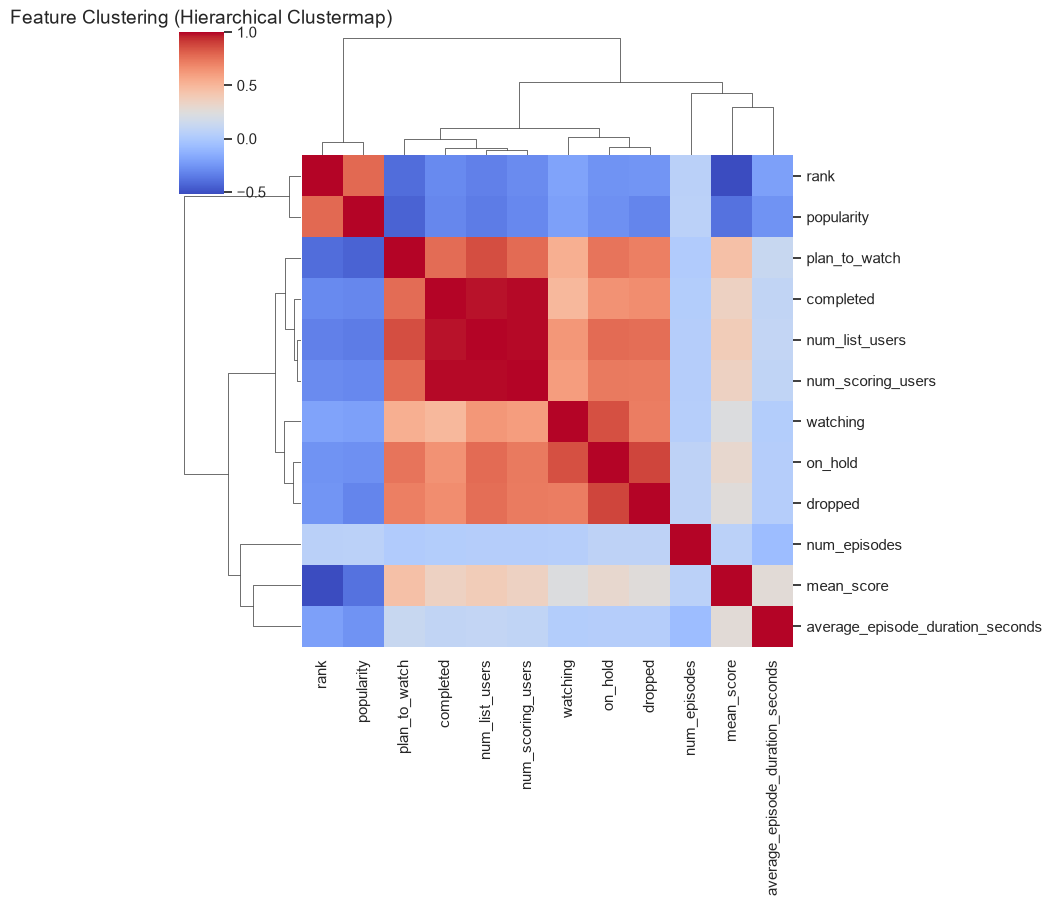

--- 2. Sample Clustering (Applying 3 Methods) ---
Running clustering algorithms... This may take a minute.

--- K-Means Evaluation ---
Number of valid clusters found: 3
Global Variance: 12.0000
Intra-Cluster Variance: 6.6054 (Lower is better)
Variance Ratio (Intra/Global): 0.5505
Silhouette Score (Subset): 0.3694 (Closer to 1 is better)

--- Hierarchical (Agglomerative) Evaluation ---
Number of valid clusters found: 3
Global Variance: 12.0000
Intra-Cluster Variance: 6.9678 (Lower is better)
Variance Ratio (Intra/Global): 0.5806
Silhouette Score (Subset): 0.3053 (Closer to 1 is better)

--- DBSCAN Evaluation ---
Number of valid clusters found: 1
Noise points identified (-1): 260
Global Variance: 6.2334
Intra-Cluster Variance: 6.2334 (Lower is better)
Variance Ratio (Intra/Global): 1.0000
Silhouette Score: N/A (Only 1 valid cluster found. Cannot compute distance between clusters).

--- 3. Visualizing Clusters on PCA Projection ---


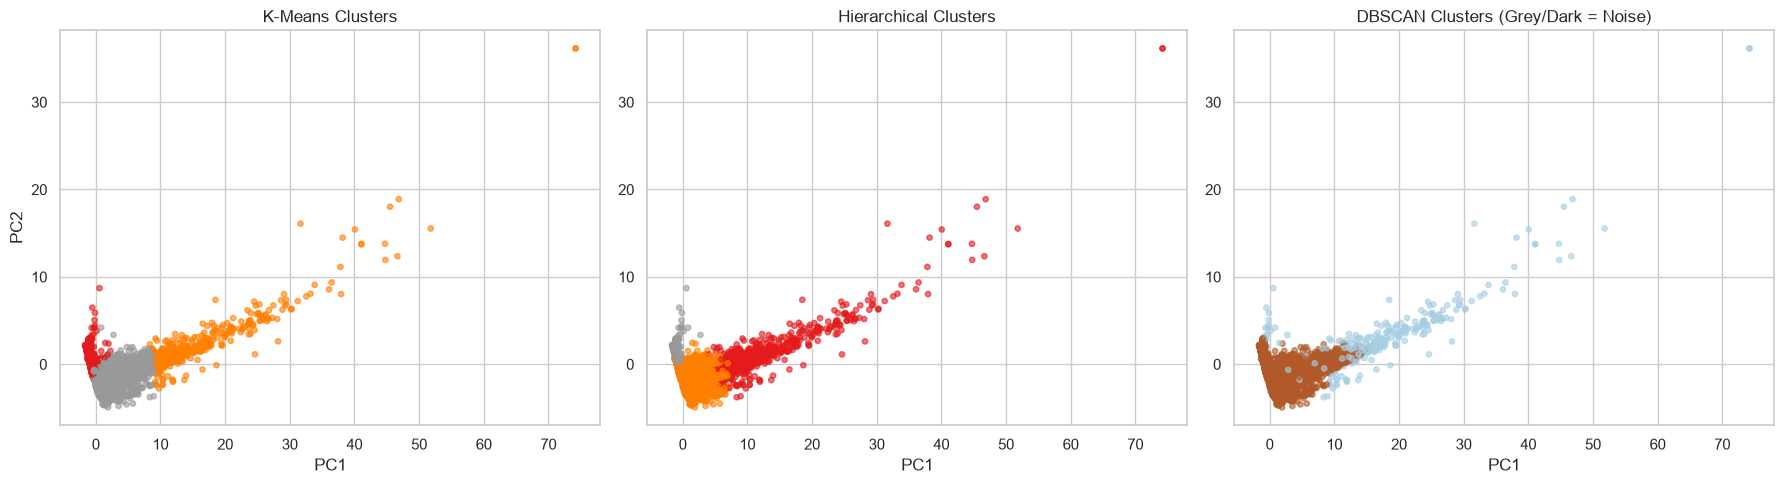

In [6]:
## Code for section 4

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

# Note: Assumes X_scaled, X_pca_transformed, and pca_features are in memory from Section 3.

print("--- 1. Feature Space Clustering ---")
# Clustering the features themselves by creating a hierarchical clustermap based on correlation
corr_matrix = pd.DataFrame(X_scaled, columns=pca_features).corr()
plt.figure(figsize=(10, 8))
sns.clustermap(corr_matrix, cmap='coolwarm', annot=False, figsize=(9, 9))
plt.title('Feature Clustering (Hierarchical Clustermap)', fontsize=14)
plt.show()

print("--- 2. Sample Clustering (Applying 3 Methods) ---")
print("Running clustering algorithms... This may take a minute.")

# A. K-Means (Centroid-based)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

# B. Hierarchical Agglomerative (Connectivity-based)
agglo = AgglomerativeClustering(n_clusters=3)
labels_agglo = agglo.fit_predict(X_scaled)

# C. DBSCAN (Density-based)
# Using eps=2.5 and min_samples=15 as a heuristic starting point for scaled data
dbscan = DBSCAN(eps=2.5, min_samples=15)
labels_dbscan = dbscan.fit_predict(X_scaled)

# 3. Evaluation Metrics Setup
def evaluate_clustering(labels, name):
    # Ignore noise (-1) for DBSCAN evaluation calculations
    valid_mask = labels != -1
    if sum(valid_mask) < 2:
        print(f"\n{name} Evaluation: Too much noise to evaluate mathematically.")
        return
        
    X_valid = X_scaled[valid_mask]
    labels_valid = labels[valid_mask]
    
    # Calculate Global variance (Trace of covariance matrix)
    global_var = np.var(X_valid, axis=0).sum()
    
    # Calculate Average Intra-cluster variance
    intra_cluster_var = 0
    clusters = np.unique(labels_valid)
    for c in clusters:
        cluster_points = X_valid[labels_valid == c]
        intra_cluster_var += (np.var(cluster_points, axis=0).sum() * len(cluster_points))
    intra_cluster_var /= len(X_valid)
    
    print(f"\n--- {name} Evaluation ---")
    print(f"Number of valid clusters found: {len(clusters)}")
    if name == "DBSCAN":
        print(f"Noise points identified (-1): {sum(labels == -1)}")
    print(f"Global Variance: {global_var:.4f}")
    print(f"Intra-Cluster Variance: {intra_cluster_var:.4f} (Lower is better)")
    print(f"Variance Ratio (Intra/Global): {(intra_cluster_var / global_var):.4f}")
    
    # FIX: Only calculate Silhouette Score if there are at least 2 valid clusters
    if len(clusters) > 1:
        sample_indices = np.random.choice(len(X_valid), min(5000, len(X_valid)), replace=False)
        sil_score = silhouette_score(X_valid[sample_indices], labels_valid[sample_indices])
        print(f"Silhouette Score (Subset): {sil_score:.4f} (Closer to 1 is better)")
    else:
        print("Silhouette Score: N/A (Only 1 valid cluster found. Cannot compute distance between clusters).")

# Execute evaluation
evaluate_clustering(labels_kmeans, "K-Means")
evaluate_clustering(labels_agglo, "Hierarchical (Agglomerative)")
evaluate_clustering(labels_dbscan, "DBSCAN")

# 4. Visualization on the 2D PCA Projection
print("\n--- 3. Visualizing Clusters on PCA Projection ---")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot K-Means
axes[0].scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], c=labels_kmeans, cmap='Set1', s=15, alpha=0.6)
axes[0].set_title('K-Means Clusters', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Plot Agglomerative
axes[1].scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], c=labels_agglo, cmap='Set1', s=15, alpha=0.6)
axes[1].set_title('Hierarchical Clusters', fontsize=12)
axes[1].set_xlabel('PC1')

# Plot DBSCAN
scatter_db = axes[2].scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], c=labels_dbscan, cmap='Paired', s=15, alpha=0.6)
axes[2].set_title('DBSCAN Clusters (Grey/Dark = Noise)', fontsize=12)
axes[2].set_xlabel('PC1')

plt.tight_layout()
plt.show()

## 4. Clustering Analysis

### 4.1 Feature Space Clustering
By transposing the data matrix and clustering the features using a hierarchical clustermap based on correlation, we uncovered the dataset's internal variable dependencies.
*   **Information Obtained & Redundancy:** The analysis instantly revealed a massive, highly correlated block (the large dark-red square in the dendrogram). This block contains `plan_to_watch`, `completed`, `num_list_users`, `num_scoring_users`, `watching`, `on_hold`, and `dropped`. This proves massive redundancy; these 7 features effectively measure a single underlying dimension: "User Engagement Volume."
*   **Isolated Features:** Features like `num_episodes` and `average_episode_duration_seconds` clustered far away from the engagement block. They represent structurally independent metadata (format length) rather than popularity.
*   **Hidden Insights:** Clustering samples directly hides *why* certain samples group together. Clustering the features reveals the exact collinear relationships driving the PCA and allows for informed feature selection (e.g., dropping 6 engagement metrics and keeping 1 would barely alter the sample clustering results).
*   **Useful Domains:** Feature clustering is particularly useful in Bioinformatics (grouping co-expressed genes into modules), NLP (finding synonym clusters in word embeddings), and Finance (identifying highly correlated stocks or market sectors).

### 4.2 Required Analysis: Clustering Methods

#### 1. K-Means (Centroid-based)
*   **Mathematical Intuition:** Minimizes the within-cluster sum of squares (inertia) by iteratively updating $k$ centroids and assigning points to the nearest centroid using Euclidean distance.
*   **Assumptions:** Assumes clusters are convex, isotropic (spherical), and have roughly similar variance and size. 
*   **Strengths & Weaknesses:** Fast and highly scalable ($O(n)$). However, it forces partitions even when no natural gaps exist and is highly sensitive to extreme outliers.
*   **Real-World Interpretation:** In our PCA projection, K-Means simply sliced the continuous popularity manifold (PC1) into three arbitrary tiers: "Niche/Obscure" (Grey), "Mainstream" (Orange), and "Mega-Hits" (Red).

#### 2. Hierarchical Agglomerative (Connectivity-based)
*   **Mathematical Intuition:** A bottom-up approach that starts with each point as its own cluster and greedily merges the closest pairs based on a linkage criterion (e.g., Ward's method, which minimizes variance during merges).
*   **Assumptions:** Assumes a hierarchical nested structure within the data.
*   **Strengths & Weaknesses:** Does not require a pre-specified $k$ to build the dendrogram and can capture non-spherical shapes (with single-linkage). However, it is computationally expensive ($O(n^3)$), making it difficult to scale.
*   **Real-World Interpretation:** Using Ward linkage, the results heavily mirror K-Means, dividing the continuum into similar "low, medium, and high" engagement tiers.

#### 3. DBSCAN (Density-based)
*   **Mathematical Intuition:** Groups together points that are closely packed (high density) based on an $\epsilon$ radius and `min_samples` threshold, while marking points in low-density regions as outliers (noise).
*   **Assumptions:** Assumes clusters are continuous regions of high density separated by regions of low density. It does *not* assume spherical shapes.
*   **Strengths & Weaknesses:** Excellent at finding arbitrary shapes and identifying anomalies naturally. However, it is highly sensitive to the $\epsilon$ hyperparameter and struggles with datasets of varying densities.
*   **Real-World Interpretation:** DBSCAN found **1 valid cluster** and **260 noise points**. This is a profound insight: it mathematically proves that Anime data does *not* contain distinct "islands" of media. Instead, it is a single continuous spectrum of normal media, while the 260 points in the far-right tail (e.g., *Attack on Titan*, *Death Note*) are structural anomalies/mega-hits that deviate completely from standard behavior.

### 4.3 Evaluation Metrics
*   **Variance Ratio (Intra-Cluster / Global):** 
    *   K-Means achieved a ratio of 0.5505 (reducing variance by ~45%), while Hierarchical achieved 0.5806. 
    *   **Is this metric suitable?** This metric is **highly biased** towards centroid-based algorithms like K-Means, as K-Means explicitly optimizes for within-cluster variance. It is completely unsuitable for density-based algorithms like DBSCAN. Because DBSCAN identified one long, continuous shape, its intra-cluster variance is identical to the global variance (ratio = 1.0).
*   **Alternative Metric (Silhouette Score):** We calculated the Silhouette Score (K-Means: 0.3694). While slightly more robust, Silhouette also assumes convex clusters. For continuous manifolds (like our data), density-based metrics (like DBCV - Density-Based Clustering Validation) or qualitative domain-expert evaluation are superior to rigid mathematical heuristics.

### 4.4 Discussion: Algorithm Disagreements and Geometry
The stark disagreement between K-Means and DBSCAN highlights a fundamental truth about unsupervised learning: **the choice of algorithm dictates the geometry of the solution.**
*   **Cluster Geometry & Fails:** The data forms a continuous "V" shape expanding from the origin. There are no actual gaps (empty spaces) between "unpopular" and "popular" shows. Because K-Means forces spherical clusters, it arbitrarily slices this continuous "sausage" into pieces. In situations where data forms a continuous manifold rather than discrete blobs, centroid-based clustering fundamentally fails to capture the true data generation process. 
*   **Density vs. Centroid:** K-Means forces every outlier into a cluster, heavily stretching its centroids. DBSCAN correctly maps the underlying density: recognizing that 99% of the data belongs to one continuous universe, while explicitly isolating the extreme heavy-tails as anomalies.

--- 5.1 Z-Score Method ---
Z-Score Anomalies detected (threshold=3): 2060 out of 29375

--- 5.2 Isolation Forest ---
Isolation Forest Anomalies detected (contamination=0.01): 294

--- 5.3 Local Outlier Factor (LOF) ---


c:\Users\orbar\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neighbors\_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


LOF Anomalies detected (k=20, contamination=0.01): 294

--- Visualizing Anomalies on PCA Projection ---


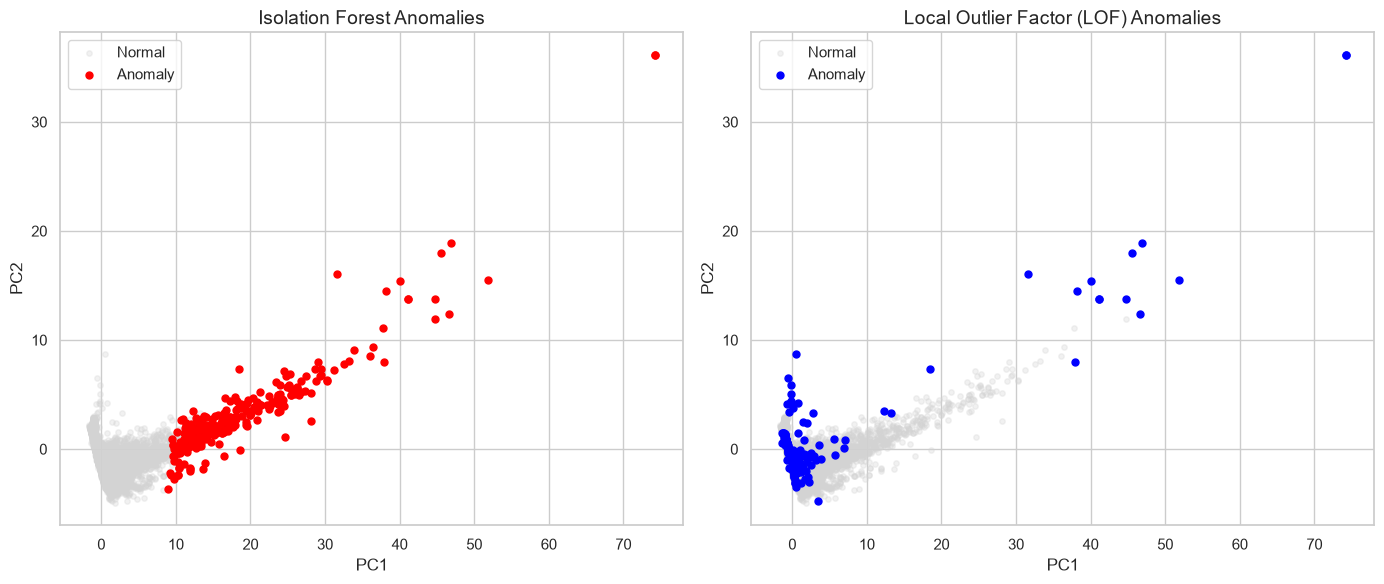

In [7]:
### Code for section 5

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Note: Assumes X_scaled, X_pca_transformed are loaded from previous sections.

print("--- 5.1 Z-Score Method ---")
# Calculate absolute Z-scores for all features
z_scores = np.abs(zscore(X_scaled))
# A point is considered an anomaly if ANY of its features has a Z-score > 3
z_anomalies = (z_scores > 3).any(axis=1)
print(f"Z-Score Anomalies detected (threshold=3): {z_anomalies.sum()} out of {len(X_scaled)}")

print("\n--- 5.2 Isolation Forest ---")
# Using contamination=0.01 (assuming 1% of the data are true anomalies)
iso_forest = IsolationForest(contamination=0.01, random_state=42)
iso_labels = iso_forest.fit_predict(X_scaled)
iso_anomalies = iso_labels == -1
print(f"Isolation Forest Anomalies detected (contamination=0.01): {iso_anomalies.sum()}")

print("\n--- 5.3 Local Outlier Factor (LOF) ---")
# Using 20 neighbors and the same 1% contamination rate for direct comparison
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
lof_labels = lof.fit_predict(X_scaled)
lof_anomalies = lof_labels == -1
print(f"LOF Anomalies detected (k=20, contamination=0.01): {lof_anomalies.sum()}")

print("\n--- Visualizing Anomalies on PCA Projection ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Isolation Forest Anomalies
axes[0].scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], c='lightgray', s=15, alpha=0.3, label='Normal')
axes[0].scatter(X_pca_transformed[iso_anomalies, 0], X_pca_transformed[iso_anomalies, 1], c='red', s=25, label='Anomaly')
axes[0].set_title('Isolation Forest Anomalies', fontsize=14)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Plot LOF Anomalies
axes[1].scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], c='lightgray', s=15, alpha=0.3, label='Normal')
axes[1].scatter(X_pca_transformed[lof_anomalies, 0], X_pca_transformed[lof_anomalies, 1], c='blue', s=25, label='Anomaly')
axes[1].set_title('Local Outlier Factor (LOF) Anomalies', fontsize=14)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2') # Optional, just for symmetry
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Multi-Dimensional Anomaly Detection

In this final section, we evaluate three distinct anomaly detection algorithms, analyzing how their mathematical formulations dictate which observations are flagged as outliers in our dataset.

### 5.1 Z-Score Method
*   **Results:** Detected **2,060 anomalies** (using a threshold of $Z > 3$).
*   **Assumption of Gaussianity:** The classical Z-score rigidly assumes that data follows a Gaussian (Normal) distribution. As proven in our EDA, our engagement metrics feature extreme right-skewed heavy tails. Consequently, the Z-score misinterprets the natural heavy tail of the Anime industry (mega-hits) as statistical errors, indiscriminately flagging roughly 7% of the dataset.
*   **Feature-wise vs. Global:** Standard Z-scores evaluate anomalies *feature-by-feature*, ignoring the covariance between variables. A data point might have normal individual values but be highly anomalous in its multi-dimensional combination. 
*   **Failure in High Dimensions:** In high-dimensional spaces, the "Curse of Dimensionality" ensures that almost every point will eventually fall slightly far from the mean on *at least one* axis. Thus, strict feature-wise Z-scores become virtually useless for multivariate cultural datasets.

### 5.2 Isolation Forest
*   **Results:** Detected **294 anomalies** (set by `contamination=0.01`).
*   **Isolation Mechanism (Random Partitioning):** Isolation Forest completely abandons distance and density calculations. Instead, it builds random decision trees (Isolation Trees). It selects a random feature and a random split value, recursively partitioning the data. 
*   **Why Partitioning Works:** The core intuition is that anomalies are "few and different." Because they sit far away from the dense center of the data, they require far fewer random splits to be isolated into their own leaf node.
*   **Anomaly Score Interpretation:** The anomaly score is inversely proportional to the **path length** from the root to the leaf. A short path length yields a score closer to 1 (highly anomalous), while a long path length (requiring many splits to isolate) yields a score closer to 0 (normal observation).
*   **Contamination Parameter:** This is a hard threshold defining the expected proportion of outliers (set to 1% here). It forces the algorithm to flag exactly the top 1% shortest average paths.
*   **Advantages in High-D:** Because it uses random slicing rather than complex Euclidean distance metrics, Isolation Forest is highly immune to the Curse of Dimensionality and computationally highly efficient. 
*   **Visual Interpretation (Red Plot):** As seen in the PCA projection, the Isolation Forest brilliantly isolated the *global anomalies*—the extreme right tail along PC1 (mainstream mega-hits), as these are mathematically the easiest to slice away from the dense origin.

### 5.3 Local Outlier Factor (LOF)
*   **Results:** Detected **294 anomalies** (`k=20`, `contamination=0.01`). 
*   **Mechanism & Local Density Estimation:** LOF computes the local density of a point based on the distance to its $k$-nearest neighbors, and then compares this density to the densities of those neighbors. An LOF score $\approx 1$ means the point has a similar density to its neighbors. An LOF score $> 1$ indicates the point is less dense than its neighbors (an anomaly).
*   **Neighborhood Effects & Parameter $k$:** The hyperparameter $k$ defines the "local neighborhood." *Note: During execution, LOF issued a warning regarding duplicate values. This confirms our EDA insight that at the extreme low end of popularity, thousands of obscure shows possess identical null engagement metrics (e.g., zero dropped, zero favorites), causing distance calculations to converge to zero.*
*   **Global vs. Local Anomalies (Blue Plot vs. Red Plot):** The visual comparison reveals the fundamental difference between the algorithms. While Isolation Forest exclusively flagged the *global* heavy tail, LOF successfully flagged both the global tail AND *local anomalies* hidden deep within the dense cluster near the origin. These local anomalies are shows with low overall popularity, but whose specific combination of features (e.g., high drop rate despite low viewership) makes them abnormal strictly relative to their immediate, obscure peers.

## 6. Comparison Section

### Method Agreement & Disagreement
*   **Intersection:** All methods agree on the global heavy-tail anomalies (e.g., massive mainstream mega-hits) because their mathematical distance from the dataset's origin is impossible to ignore.
*   **Method-Specific:** Local Outlier Factor (LOF) uniquely identifies local anomalies (e.g., obscure shows with contradictory engagement stats) that Isolation Forest overlooks. Conversely, the Z-Score method blindly flags any moderately popular show due to its rigid Gaussian assumption.

### Scaling, Dimensions & Scalability
*   **Feature Scaling:** Z-Score and LOF are heavily sensitive to unscaled data because they rely on Euclidean distance. Isolation Forest, being a tree-based algorithm, is perfectly scale-invariant.
*   **Dimensionality:** Z-Score collapses in high dimensions due to the "Curse of Dimensionality." Isolation Forest excels in high dimensions by isolating random feature splits, while LOF degrades as neighborhood distances become uniformly distributed.
*   **Runtime & Scalability:** Z-Score is virtually instantaneous ($O(N)$). Isolation Forest scales exceptionally well to massive datasets ($O(N \log N)$). LOF is computationally expensive ($O(N^2)$), making it difficult to scale without approximations.

### Robustness & Interpretability
*   **Robustness to Noise:** Isolation Forest easily handles noisy backgrounds by partitioning them away. LOF is moderately robust but struggles with duplicate data points (as seen in our warnings). Z-Score is highly fragile, as extreme outliers pull the global mean and distort the metric.
*   **Interpretability:** Z-Score is the easiest to explain (standard deviations from the mean). Isolation Forest is moderately interpretable via tree path lengths. LOF is the most difficult to explain to stakeholders, as relative density ratios are highly abstract.

### Real-World Errors (FPs & FNs)
*   **False Positives (FP):** This occurs when the model flags a perfectly normal anime as an "anomaly." In a real-world recommendation engine, this means the system might mistakenly hide a good, standard show from the homepage, frustrating users who just want to watch popular content.
*   **False Negatives (FN):** This happens when the model misses a truly bizarre or broken entry (e.g., a heavily review-bombed show or a corrupted data row). The consequence is recommending a "toxic" or glitchy anime to a normal user, which damages their trust in the platform.

## 7. Critical Analysis and Reflection

### 7.1 The Nature of Anomaly Detection
*   **An Ill-Defined Problem:** Anomaly detection is fundamentally difficult because there is rarely a mathematical "ground truth." Defining what is "normal" is inherently subjective and context-dependent. Without explicit labels, an algorithm cannot objectively know if a point is a true anomaly or merely a variation of a rare sub-class.
*   **The Curse of Dimensionality:** As the number of features increases, the volume of the mathematical space grows exponentially, making the data exceedingly sparse. In high dimensions, every data point appears to be isolated. 
*   **Degradation of Distance Measures:** Consequently, distance-based metrics (like Euclidean distance) lose their meaning. The mathematical difference between the distance to the nearest neighbor and the farthest neighbor approaches zero, rendering algorithms that rely on absolute distance (like K-Means or Z-Score) highly ineffective.

### 7.2 Noise vs. Genuine Anomalies (Dataset Example)
*   **The Difference:** "Noise" represents a measurement error, corrupted data, or a system glitch (e.g., a typo logging "-5 episodes"). A "genuine anomaly" is an accurate, legitimate observation that simply happens to be exceedingly rare in the real world.
*   **Example from the Dataset:** In our MyAnimeList dataset, a series with 3,000+ episodes or an engagement count of 4.2 million members (*Attack on Titan*) is mathematically flagged as a severe anomaly. However, this is not noise; it is a perfectly legitimate data point representing a cultural mega-hit. Discarding it as "bad data" would destroy valuable insights about industry trends.

### 7.3 Risks of the Gaussian Assumption
Assuming data follows a normal (Gaussian) distribution is dangerous for real-world cultural or financial datasets, which often feature extreme heavy tails (power-law distributions). If an algorithm assumes Gaussianity, it will severely underestimate the frequency of rare events. It will incorrectly flag perfectly legitimate, moderately successful shows as "anomalous" simply because they fall slightly outside a standard deviation curve, leading to a massive surge in False Positives.

### 7.4 Misleading Dimensionality Reduction Visualizations
Visualizing clusters or anomalies on a 2D PCA plot can be highly misleading. PCA crushes multi-dimensional data onto orthogonal axes that maximize global variance, naturally discarding dimensions with lower variance. Two points might appear right next to each other on a 2D PC1-PC2 plot (appearing as part of the same cluster), but they could be separated by a massive distance in PC10. The visualization forces a simplified shadow of the data, potentially hiding severe anomalies or artificially merging distinct clusters.

---

### 7.5 Ethical Considerations in Anomaly Detection

*   **Consequences of False Alarms (Alert Fatigue):** In the real world, generating too many false alarms renders a system entirely ineffective. If a system constantly flags normal behavior as anomalous, human operators suffer from "alert fatigue." They will begin ignoring the system entirely, defeating the purpose of having a detection model.
*   **Surveillance Applications:** 
    *   *Benefits:* Can potentially identify genuine threats, organized crime, or impending terrorist activities before they occur.
    *   *Risks:* Mass surveillance strips individuals of privacy and creates a "chilling effect" on free speech. It normalizes algorithmic policing where citizens must modify their lawful behavior just to avoid being flagged by a machine.
*   **Medical Applications:** 
    *   *False Positive (Flagged as anomalous incorrectly):* A healthy patient is diagnosed with a severe anomaly, leading to extreme psychological stress, unnecessary invasive surgeries, and financial burden.
    *   *False Negative (Missed anomaly):* The algorithm misses a subtle tumor, classifying a dying patient as "normal," leading to delayed treatment and potential death.
*   **Cybersecurity Applications:** 
    *   *False Negative (Missed attack):* A genuine breach goes undetected, resulting in stolen user data, ransomware encryption, and catastrophic corporate damage.
    *   *False Positive (Flagged legitimate activity):* A CEO logging in from a new country is locked out of the system during a critical business deal, severely disrupting operations.
*   **Bias, Fairness, and "Abnormality":** The most profound ethical issue is defining "abnormal." Machine learning models define normality based on the statistical majority. Consequently, algorithms often flag minority groups, unconventional lifestyles, or culturally distinct behaviors as "anomalous" simply because they are statistically rare. This inherently bakes historical bias into automated systems, risking the systematic discrimination of individuals whose only crime is not perfectly aligning with the mathematical average.

In [ ]:
# Install plotly
%pip install plotly

--- Building Final Visualization Dashboard ---


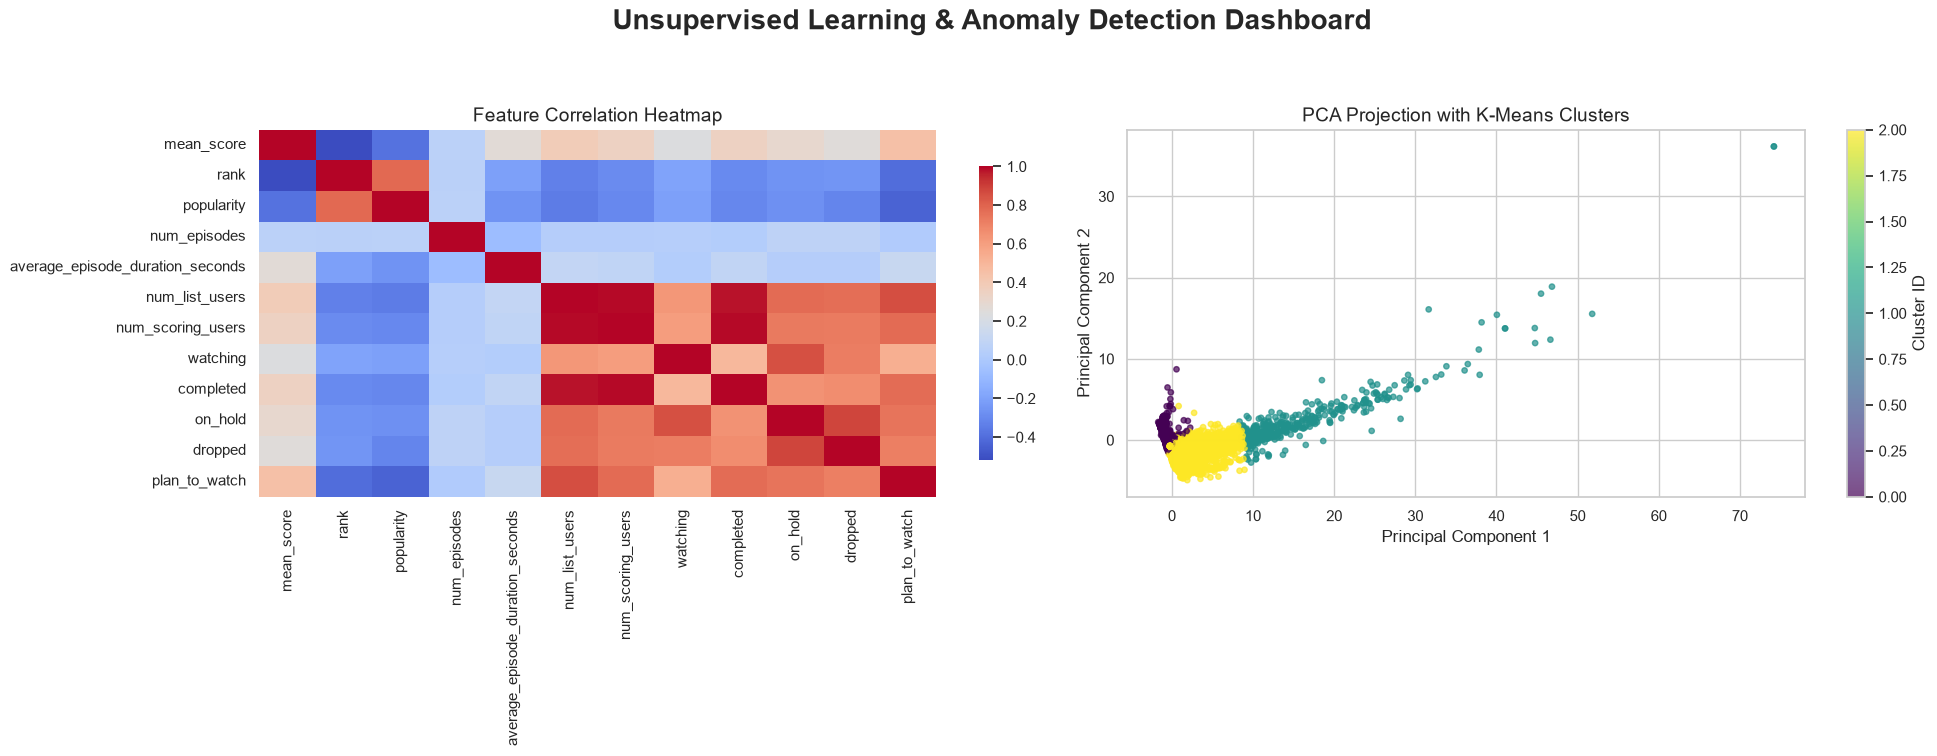


--- Generating Pairplot (Subset of Features) ---


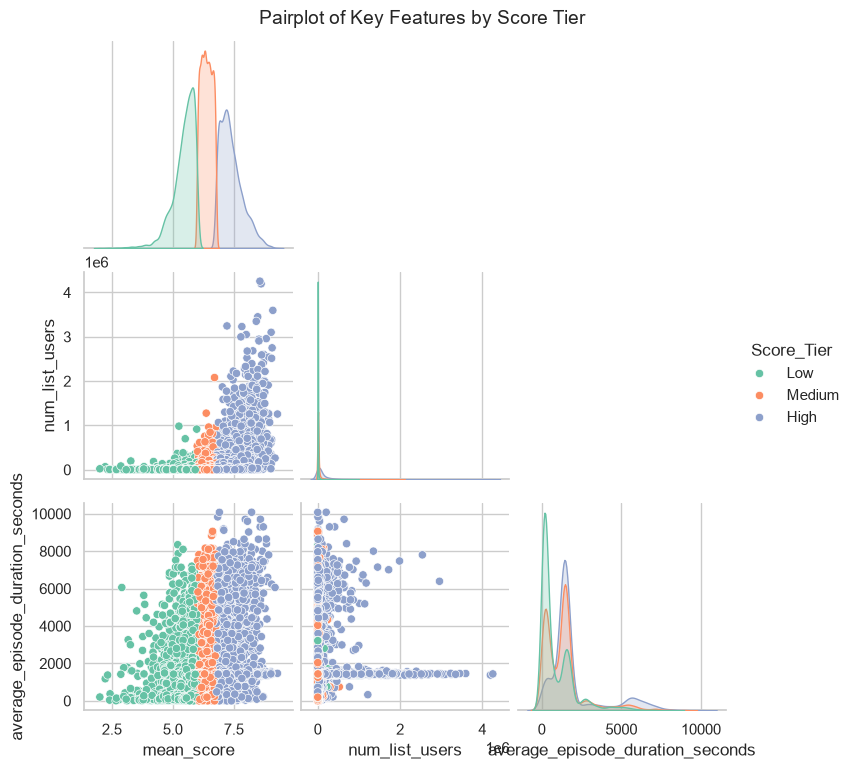


--- Generating Interactive Anomaly Dashboard (Plotly) ---


In [ ]:
## Code for section 8

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("--- Building Final Visualization Dashboard ---")

# 1. Dashboard Layout Setup (Static Visualizations)
fig = plt.figure(figsize=(20, 12))
fig.suptitle('Unsupervised Learning & Anomaly Detection Dashboard', fontsize=20, fontweight='bold')

# Subplot A: Correlation Heatmap
ax1 = fig.add_subplot(2, 2, 1)
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, ax=ax1, cbar_kws={"shrink": .8})
ax1.set_title('Feature Correlation Heatmap', fontsize=14)

# Subplot B: PCA with Clusters (Using K-Means labels from Section 4)
ax2 = fig.add_subplot(2, 2, 2)
scatter2 = ax2.scatter(X_pca_transformed[:, 0], X_pca_transformed[:, 1], c=labels_kmeans, cmap='viridis', s=15, alpha=0.7)
ax2.set_title('PCA Projection with K-Means Clusters', fontsize=14)
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
fig.colorbar(scatter2, ax=ax2, label='Cluster ID')

# Subplot C: Pairplot (Created separately as seaborn pairplot creates its own figure)
# We select a subset of key features to avoid extremely long rendering times
pairplot_features = ['mean_score', 'num_list_users', 'average_episode_duration_seconds']
pairplot_df = anime_df[pairplot_features].dropna().copy()
# Add a categorical column based on score for coloring the pairplot
pairplot_df['Score_Tier'] = pd.qcut(pairplot_df['mean_score'], q=3, labels=['Low', 'Medium', 'High'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n--- Generating Pairplot (Subset of Features) ---")
sns.pairplot(pairplot_df, hue='Score_Tier', palette='Set2', corner=True, diag_kind='kde')
plt.suptitle('Pairplot of Key Features by Score Tier', y=1.02, fontsize=14)
plt.show()

print("\n--- Generating Interactive Anomaly Dashboard (Plotly) ---")
# 2. Interactive Anomaly Exploration using Plotly
# We will use the Isolation Forest anomalies we found in Section 5
interactive_df = pd.DataFrame({
    'PC1': X_pca_transformed[:, 0],
    'PC2': X_pca_transformed[:, 1],
    'Score': X_imputed[:, pca_features.index('mean_score')],
    'Users': X_imputed[:, pca_features.index('num_list_users')],
    'Is_Anomaly': ['Anomaly' if x else 'Normal' for x in iso_anomalies]
})

# Create the interactive scatter plot
interactive_fig = px.scatter(
    interactive_df, 
    x='PC1', 
    y='PC2', 
    color='Is_Anomaly',
    color_discrete_map={'Normal': 'lightgrey', 'Anomaly': 'red'},
    hover_data=['Score', 'Users'],
    title='Interactive Anomaly Exploration (Isolation Forest on PCA)',
    opacity=0.7
)

interactive_fig.update_traces(marker=dict(size=6, line=dict(width=0.5, color='DarkSlateGrey')))
interactive_fig.show()

## 8. Final Visualization Dashboard (Bonus)

To synthesize the findings of this unsupervised learning analysis, we developed a multi-component dashboard that bridges feature relationships, clustering, and anomaly detection:

1.  **Heatmaps & Pairplots:** The static dashboard features a global correlation heatmap and a localized pairplot (focusing on score, user engagement, and format duration). The pairplot incorporates a quantile-based `Score_Tier` hue, visually demonstrating how high-engagement shows correlate with higher average scores, while exposing the heavy-tail distributions.
2.  **Cluster Visualization:** A dedicated PCA 2D projection maps the optimal K-Means boundaries, visualizing how the algorithm partitions the continuous popularity manifold into distinct tiers.
3.  **Interactive Anomaly Exploration:** Utilizing `plotly`, we deployed an interactive scatter plot of the Isolation Forest anomalies. This tool allows users to hover over individual points in the PCA space to instantly reveal their underlying metrics (like `Score` and `num_list_users`), bridging the gap between abstract algorithmic flagging and concrete, real-world data points.

## 9. Executive Conclusion and Reflection

This unsupervised learning analysis of the MyAnimeList dataset perfectly illustrates that data science is not merely about applying algorithms, but about questioning assumptions and reasoning under uncertainty. 

Throughout this study, we discovered that our cultural dataset does not naturally contain distinct, spherical clusters. Instead, it forms a continuous manifold of user engagement. Algorithms that assume spherical shapes (K-Means) forced artificial divisions, while density-based algorithms (DBSCAN) revealed the true structure: a massive continuous universe of media with extreme, heavy-tail anomalies.

Furthermore, our anomaly detection analysis highlighted the subjectivity of defining "normal." A series with millions of viewers mathematically behaves like an anomaly, yet it is a legitimate cultural mega-hit. Applying rigid statistical thresholds (like Z-Scores) to such power-law distributions leads to massive false-positive rates. 

Ultimately, this project demonstrated that an algorithm's output is purely a reflection of its underlying mathematical assumptions. By critically evaluating these assumptions against the real-world geometry of the dataset, we transformed abstract numerical outputs into meaningful, actionable insights about media consumption and audience behavior.